# Additional Charts for Executive Presentation


### 1. Import python Libraries

In [147]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import joblib
import xgboost as xgb

### 2. Setup jupyternotebook 

In [148]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows
# Force pandas to display 2 decimal places (no scientific notation)
pd.options.display.float_format = '{:.2f}'.format

### 3. Import the file final file before encoding

In [149]:
train_filepath = '../data/processed/neiss_feature-engineered_train_data_b4_encoding.parquet'
train_data= pd.read_parquet(train_filepath)
encoded_train_data_filepath = '../data/processed/neiss_feature-engineered_train_data.parquet'
encoded_train_data = pd.read_parquet(encoded_train_data_filepath)

In [150]:
train_data.info()

<class 'pandas.DataFrame'>
Index: 5120468 entries, 6181068 to 3926627
Data columns (total 36 columns):
 #   Column             Dtype         
---  ------             -----         
 0   data_year          int64         
 1   CPSC_Case_Number   int64         
 2   Treatment_Date     datetime64[us]
 3   Age                float64       
 4   Sex                int64         
 5   Race               int64         
 6   Other_Race         str           
 7   Hispanic           float64       
 8   Body_Part          int64         
 9   Diagnosis          int64         
 10  Other_Diagnosis    str           
 11  Body_Part_2        float64       
 12  Diagnosis_2        float64       
 13  Other_Diagnosis_2  str           
 14  Disposition        int64         
 15  Location           int64         
 16  Fire_Involvement   int64         
 17  Product_1          str           
 18  Product_2          int64         
 19  Product_3          int64         
 20  Alcohol            float64       


In [151]:
train_data.shape

(5120468, 36)

### 6. Plot patterns in injury seviariry across demographic groups

In [152]:
# Categorizing the age groups in to bins.
train_data['age_group'] = pd.cut(train_data['Age'], bins=[-1, 4, 11, 17,29, 49, 64, 84, np.inf], 
                                  labels=['0-4 (Toddler)', '5-11 (Child)', '12-17 (Teen)', '19-29 (Young Adult)', '30-49 (Adult)', '50-64 (Middle Age)', '65-84 (Senior)', '85+ (Elderly)'])

In [153]:
train_data.head()

,data_year,CPSC_Case_Number,Treatment_Date,Age,Sex,Race,Other_Race,Hispanic,Body_Part,Diagnosis,Other_Diagnosis,Body_Part_2,Diagnosis_2,Other_Diagnosis_2,Disposition,Location,Fire_Involvement,Product_1,Product_2,Product_3,Alcohol,Drug,Narrative_1,Stratum,PSU,Weight,Hospitalized,EMS_Severity_Flag,Safety_Gear_Flag,Third_Party_Flag,Height_Risk_Flag,Water_Risk_Flag,True_Alcohol,True_Drug,Treatment_Month,Injury_Mechanism,age_group
6181068,2021,210940547,2021-09-14,48.00,1,0,OTHER,0.00,76,57,UNKNOWN,87.00,71.00,UNKNOWN,1,1,0,649,0,0,0.00,0.00,48 YOM. PT GOT GOT OFF THE TOILET TO WALK BACK...,M,24,68.72,0,0,0,0,0,0,0,0,9,Struck By,30-49 (Adult)
3981895,2015,150740666,2015-07-11,7.00,2,1,OTHER,0.00,83,59,UNKNOWN,87.00,71.00,UNKNOWN,1,0,0,1242,0,0,3.00,3.00,7YOF WITH FOOT LACERATION. PT CUT FOOT WHILE G...,V,64,15.78,0,0,0,0,0,0,2,2,7,Laceration/Cut,5-11 (Child)
850890,2007,70547594,2007-05-14,79.00,1,1,OTHER,0.00,36,57,UNKNOWN,87.00,71.00,UNKNOWN,4,1,0,4078,0,0,3.00,3.00,"LEFT TIB/FIB FRACTURE,LEFT HAND FRACTURE.PT FE...",V,95,15.18,1,0,0,0,1,0,2,2,5,Fall,65-84 (Senior)
5177385,2018,180948996,2018-09-15,13.00,1,0,OTHER,0.00,85,71,HEAT EXHAUSTION,87.00,71.00,UNKNOWN,1,9,0,5041,0,0,3.00,3.00,13YR M PLAYING BASEBALL;DX HEAT EXHAUSTION,C,20,4.94,0,0,0,0,0,0,2,2,9,Other/Unspecified,12-17 (Teen)
5858098,2020,200946031,2020-09-22,54.00,1,0,OTHER,0.00,79,57,UNKNOWN,87.00,71.00,UNKNOWN,4,1,0,1807,0,0,0.00,0.00,54 YOM FELL TO FLOOR DX: COMPRESSION FX OF L2...,M,14,78.16,1,0,0,0,0,0,0,0,9,Fall,50-64 (Middle Age)


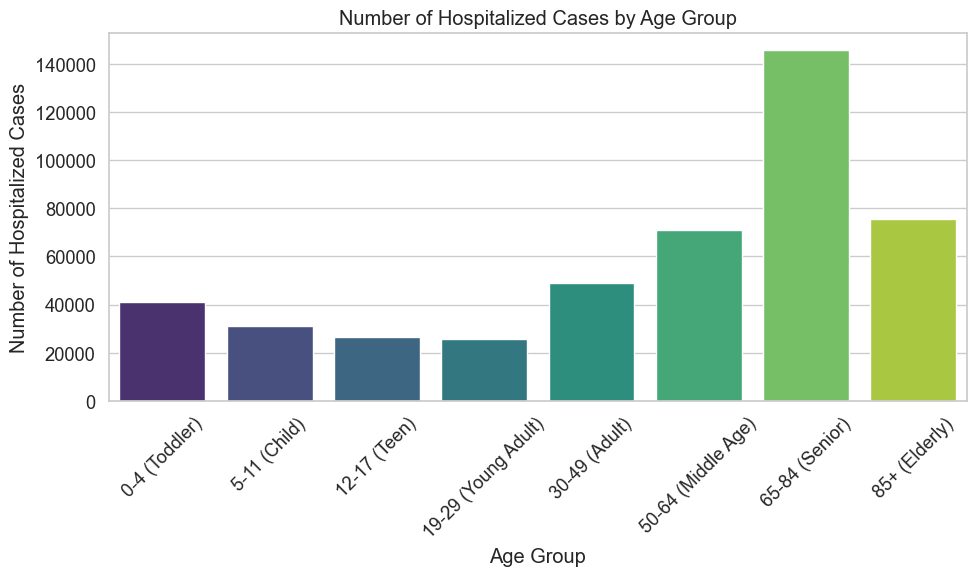

In [154]:
# Find all hospitalized cases in the dataset
hospitalized_cases = train_data[train_data['Hospitalized'] == 1]
# group the data by age group and count the number of cases in each group
hospitalized_by_age_group = hospitalized_cases.groupby('age_group').size().reset_index(name='hospitalized_count')
# sort the data by age group
hospitalized_by_age_group = hospitalized_by_age_group.sort_values('age_group')
# plot the data
plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='hospitalized_count', data=hospitalized_by_age_group, palette='viridis',
            hue = 'age_group', dodge=False)
plt.title('Number of Hospitalized Cases by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Hospitalized Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
train_data.Sex.value_counts()

Sex
1    2815539
2    2304929
Name: count, dtype: int64

In [156]:
# Create a new column for Sex with more descriptive labels
hospitalized_cases['Sex_label'] = hospitalized_cases['Sex'].map({1: 'Male', 2: 'Female', 3: 'Unknown'})
hospitalized_cases.Sex_label.value_counts()

Sex_label
Male      239643
Female    225743
Name: count, dtype: int64

In [157]:
# Create the similar stacked bar chart with the age gorups but also with the sex of the patients.
hospitalized_by_age_group_and_sex = hospitalized_cases.groupby(['age_group', 'Sex_label']).size().reset_index(name='hospitalized_count')
hospitalized_by_age_group_and_sex = hospitalized_by_age_group_and_sex.sort_values('age_group')          
hospitalized_by_age_group_and_sex.set_index('age_group', inplace=True)

In [12]:
hospitalized_by_age_group_and_sex.head(20)

,Sex_label,hospitalized_count
age_group,,
0-4 (Toddler),Female,17548
0-4 (Toddler),Male,23326
5-12 (Child),Female,13442
5-12 (Child),Male,22217
13-18 (Teen),Female,5907
13-18 (Teen),Male,18338
19-35 (Young Adult),Female,11300
19-35 (Young Adult),Male,24843
36-50 (Adult),Female,13921


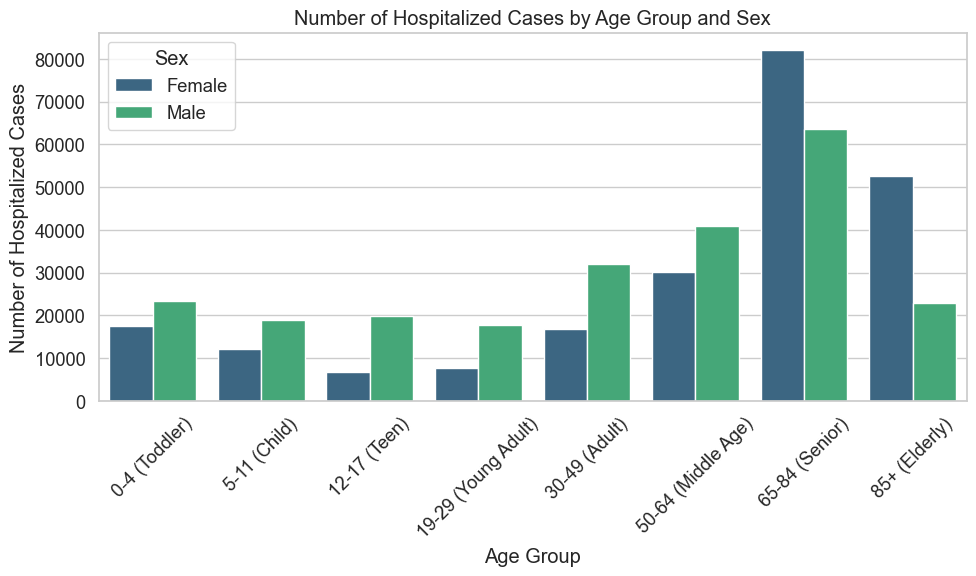

In [158]:
# Draw a bar plot with the age groups on the x-axis, the number of hospitalized cases on the y-axis, and different colors for each  sex category.
plt.figure(figsize=(10, 6))
sns.barplot(x='age_group', y='hospitalized_count', data=hospitalized_by_age_group_and_sex, palette='viridis',   hue = 'Sex_label')
plt.title('Number of Hospitalized Cases by Age Group and Sex')
plt.xlabel('Age Group')
plt.ylabel('Number of Hospitalized Cases')
plt.xticks(rotation=45)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

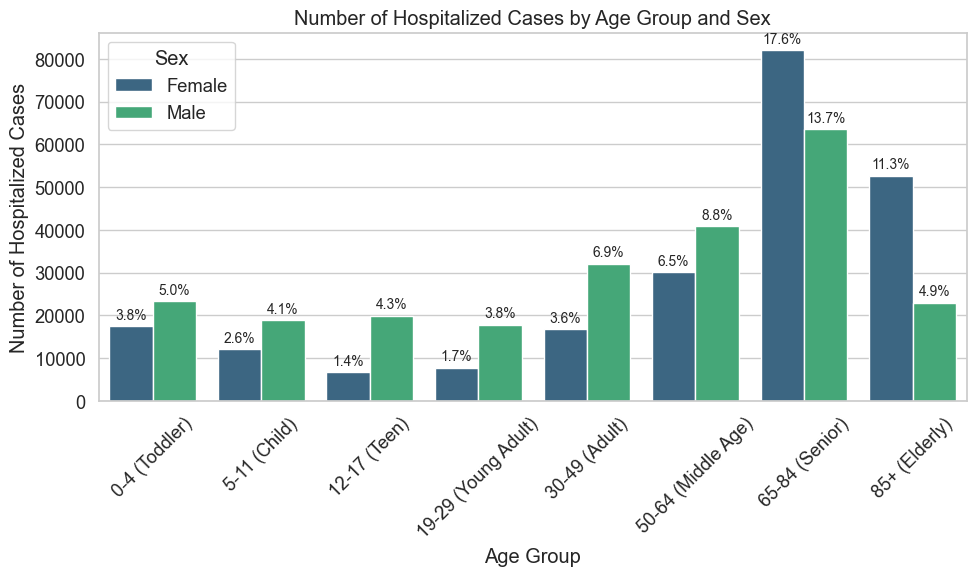

In [159]:

# 1. Calculate the total number of cases so we have a denominator for our percentages
total_cases = hospitalized_by_age_group_and_sex['hospitalized_count'].sum()

plt.figure(figsize=(10, 6))

# 2. Assign the seaborn plot to a variable 'ax' so we can manipulate it
ax = sns.barplot(
    x='age_group', 
    y='hospitalized_count', 
    data=hospitalized_by_age_group_and_sex, 
    palette='viridis',   
    hue='Sex_label'
)

plt.title('Number of Hospitalized Cases by Age Group and Sex')
plt.xlabel('Age Group')
plt.ylabel('Number of Hospitalized Cases')
plt.xticks(rotation=45)
plt.legend(title='Sex')

# 3. Loop through the bars and add the custom percentage labels
for container in ax.containers:
    # Get the height (raw count) of each bar, calculate the %, and format it
    labels = [f"{(bar.get_height() / total_cases) * 100:.1f}%" 
              for bar in container]
    
    # Attach the formatted labels to the bars
    ax.bar_label(container, labels=labels, padding=3, fontsize=10)

plt.tight_layout()
plt.show()

### 7. Plot patterns in injury seviarity across product categories

In [160]:
# Find the top 10 product categories that lead to hospitalization and plot them by age group.
neiss_product_short_dict = {
    1807: "Floors",
    1842: "Stairs",
    4076: "Beds",
    5040: "Bicycles",
    4074: "Chairs",
    611: "Bathtubs",
    649: "Toilets",
    4078: "Ladders",
    3299: "Exercise",
    1884: "Walls",
    4057: "Tables",
    679: "Sofas",
    676: "Rugs",
    1211: "Football",
    1817: "Porches",
    1931: "Blankets",
    1893: "Doors",
    1615: "Footwear",
    1686: "Coins",
    1894: "Windows"
}
top10_hospitalization_products = hospitalized_cases['Product_1'].value_counts().head(10).index.tolist()


In [161]:
neiss_product_short_dict = {
    1807: "Floors",
    1842: "Stairs",
    4076: "Beds",
    5040: "Bicycles",
    4074: "Chairs",
    611: "Bathtubs",
    649: "Toilets",
    4078: "Ladders",
    3299: "Exercise",
    1884: "Walls",
    4057: "Tables",
    679: "Sofas",
    676: "Rugs"
}
# Map the product codes to their short names
hospitalized_cases['product_category'] = hospitalized_cases['Product_1'].astype(int)  # Ensure the product codes are integers for mapping
hospitalized_cases['product_category'] = hospitalized_cases['Product_1'].map(neiss_product_short_dict)
top_10_products = hospitalized_cases['product_category'].value_counts().head(15).reset_index(name='hospitalized_count')
top_10_products.columns = ['product_category', 'hospitalized_count']
top_10_p = top_10_products.product_category.to_list()




In [162]:
train_data.info()

<class 'pandas.DataFrame'>
Index: 5120468 entries, 6181068 to 3926627
Data columns (total 37 columns):
 #   Column             Dtype         
---  ------             -----         
 0   data_year          int64         
 1   CPSC_Case_Number   int64         
 2   Treatment_Date     datetime64[us]
 3   Age                float64       
 4   Sex                int64         
 5   Race               int64         
 6   Other_Race         str           
 7   Hispanic           float64       
 8   Body_Part          int64         
 9   Diagnosis          int64         
 10  Other_Diagnosis    str           
 11  Body_Part_2        float64       
 12  Diagnosis_2        float64       
 13  Other_Diagnosis_2  str           
 14  Disposition        int64         
 15  Location           int64         
 16  Fire_Involvement   int64         
 17  Product_1          str           
 18  Product_2          int64         
 19  Product_3          int64         
 20  Alcohol            float64       


In [163]:
neiss_product_short_dict = {
    1807: "Floors",
    1842: "Stairs",
    4076: "Beds",
    5040: "Bicycles",
    4074: "Chairs",
    611: "Bathtubs",
    649: "Toilets",
    4078: "Ladders",
    3299: "Exercise",
    1884: "Walls",
    4057: "Tables",
    679: "Sofas",
    676: "Rugs",
    1211: "Football",
    1817: "Porches",
    1931: "Blankets",
    1893: "Doors",
    1615: "Footwear",
    1686: "Coins",
    1894: "Windows"
}
train_data['Product_1'] = train_data['Product_1'].astype(int)  # Ensure the product codes are integers for mapping
train_data['product_category'] = train_data['Product_1'].map(neiss_product_short_dict)

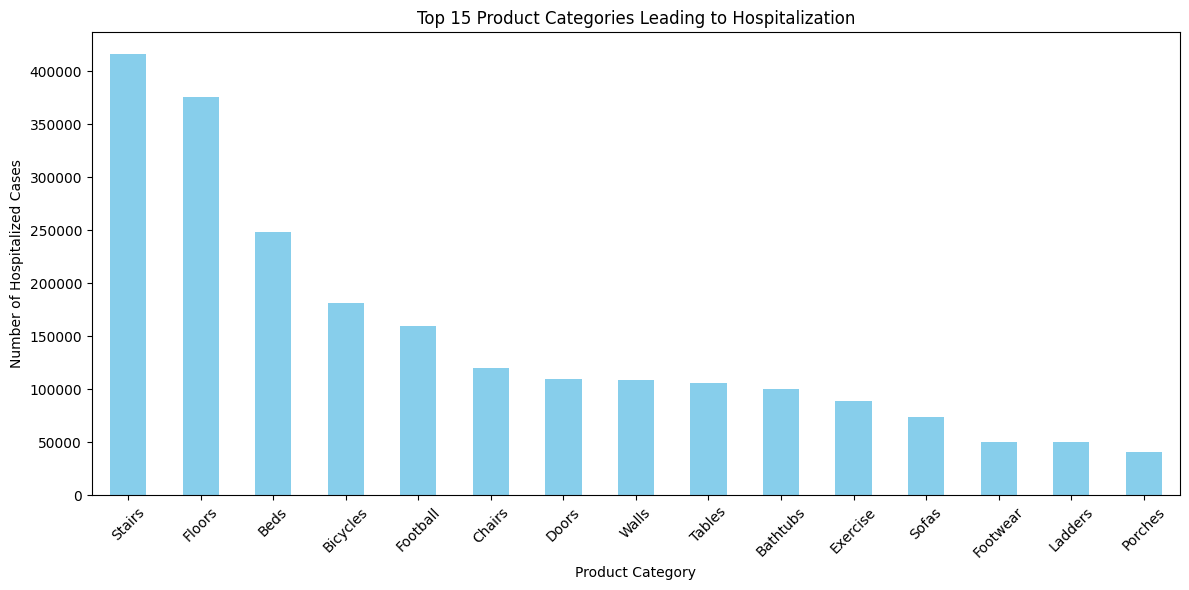

In [52]:
top_10_products = train_data.product_category.value_counts().head(15)
top_10_products.plot(kind='bar', figsize=(12, 6), color='skyblue')
plt.title('Top 15 Product Categories Leading to Hospitalization')
plt.xlabel('Product Category')
plt.ylabel('Number of Hospitalized Cases')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
    

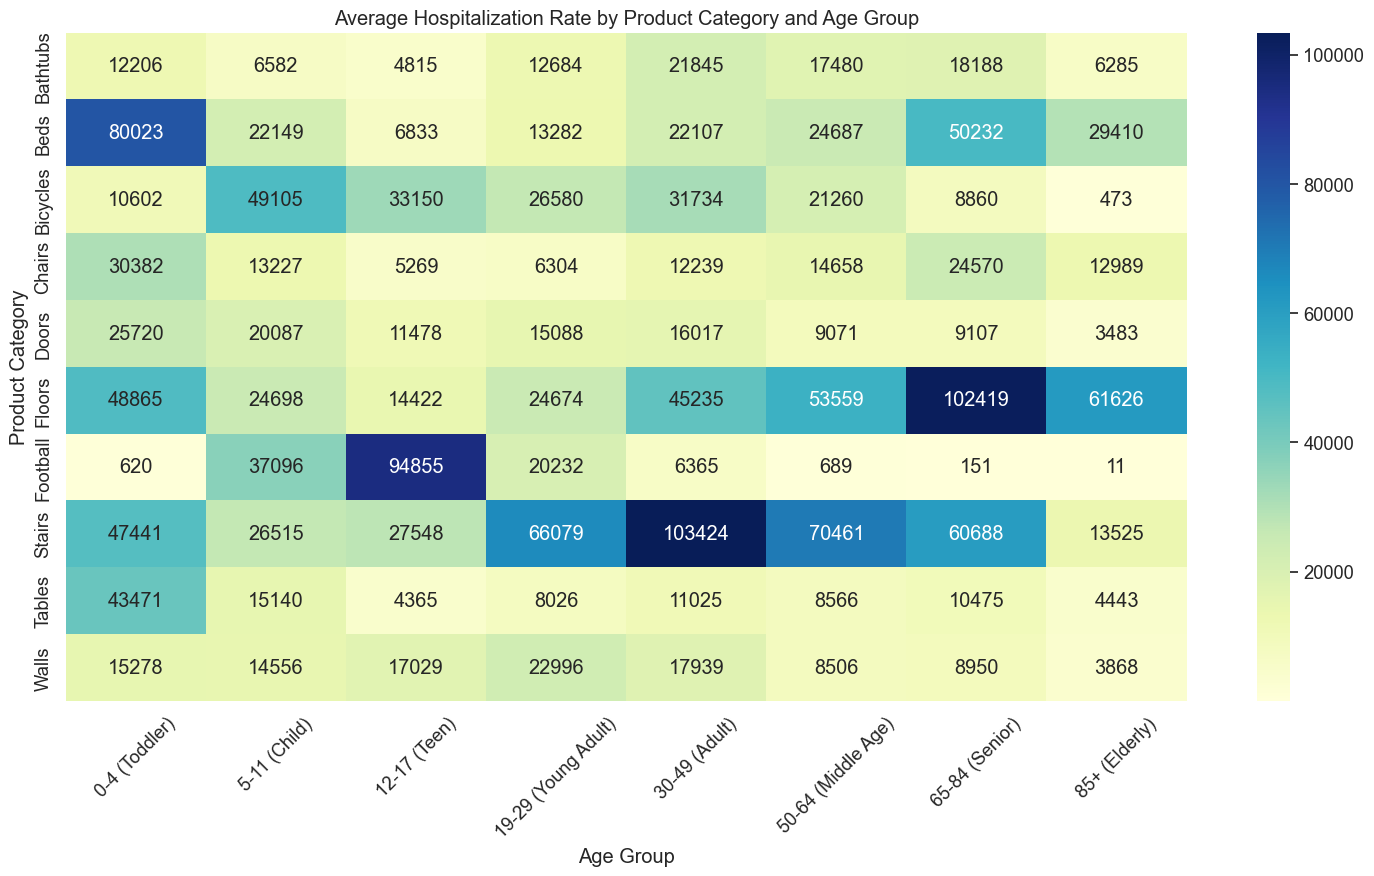

In [169]:
top_10_products = train_data['product_category'].value_counts().head(10)
top_10_products = top_10_products.reset_index()
top_10_products.columns = ['Product Category', 'Total Injuries']
top_10_product_list = top_10_products['Product Category'].to_list()
top_10_product_data = train_data[train_data['product_category'].isin(top_10_product_list)]
# create a pivot table with product categories as rows, age groups as columns, and the sum of hospitalizations as values
pivot_table = top_10_product_data.pivot_table(index='product_category', columns='age_group', values='Hospitalized', aggfunc='count', fill_value=0)
# create a heatmap to visualize the pivot table
plt.figure(figsize=(15, 9))
sns.heatmap(pivot_table, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Average Hospitalization Rate by Product Category and Age Group')
plt.xlabel('Age Group')
plt.ylabel('Product Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


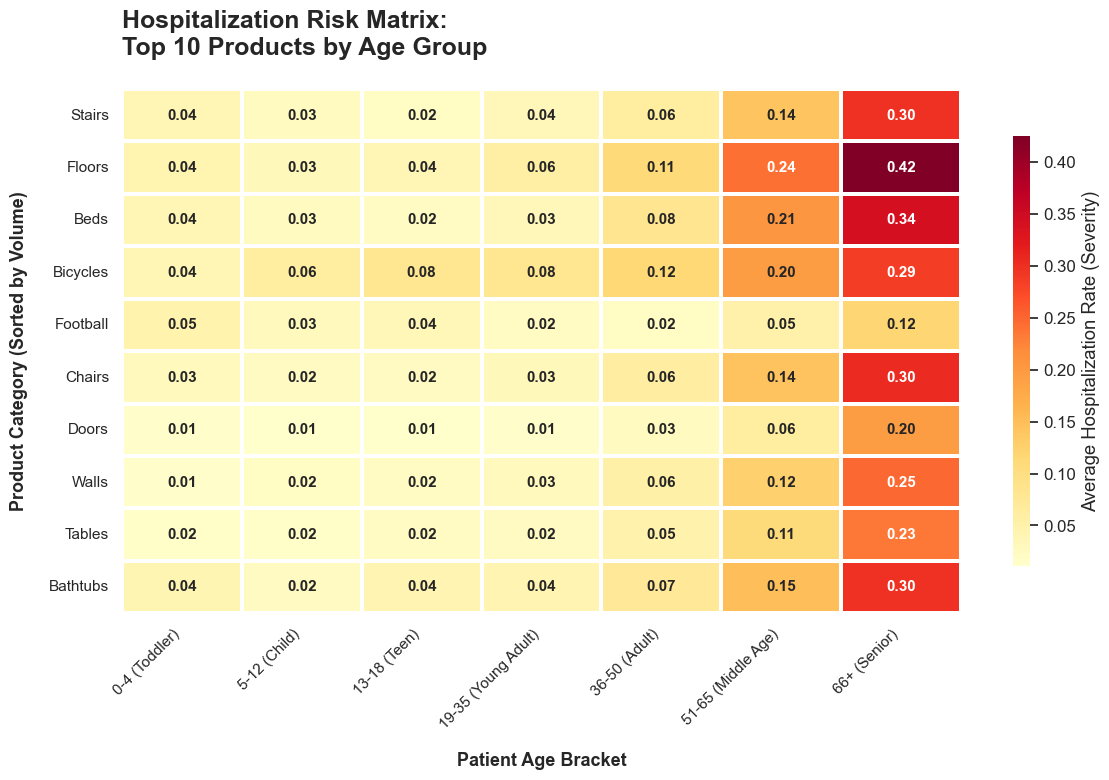

In [88]:
# 1. Clean Data Extraction & Sorting
# Get top 10 products and force a clean index
top_10_products = train_data['product_category'].value_counts().head(10).reset_index()
top_10_products.columns = ['Product Category', 'Total Injuries']

# Extract the list and filter the main dataset
top_10_list = top_10_products['Product Category'].to_list()
top_10_data = train_data[train_data['product_category'].isin(top_10_list)]

# 2. Create the Pivot Table
# We reindex the pivot table using the 'top_10_list' to guarantee the Y-axis 
# is sorted by highest injury volume to lowest, rather than alphabetically.
pivot_table = top_10_data.pivot_table(
    index='product_category', 
    columns='age_group', 
    values='Hospitalized', 
    aggfunc='mean', 
    fill_value=0
).reindex(top_10_list) 

# 3. Editorial Visual Design
sns.set_theme(style="white", font_scale=1.1)
fig, ax = plt.subplots(figsize=(12, 8))

# Draw the refined heatmap
sns.heatmap(
    pivot_table, 
    annot=True, 
    fmt=".2f", 
    cmap="YlOrRd",             # Changed to Yellow-Orange-Red for a better "risk" visual
    linewidths=1.5,            # Thicker lines for crisp cell separation
    linecolor='white',         # White borders look much more modern
    annot_kws={"size": 11, "weight": "bold"}, # Make the numbers pop
    cbar_kws={
        'label': 'Average Hospitalization Rate (Severity)',
        'shrink': 0.82,        # Elegantly shrink colorbar height
        'aspect': 25
    },
    ax=ax
)

# 4. Clean Formatting
ax.set_title('Hospitalization Risk Matrix:\nTop 10 Products by Age Group', 
             fontsize=18, fontweight='bold', pad=25, loc='left')
ax.set_xlabel('Patient Age Bracket', fontsize=13, fontweight='semibold', labelpad=15)
ax.set_ylabel('Product Category (Sorted by Volume)', fontsize=13, fontweight='semibold', labelpad=15)

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
ax.tick_params(left=False, bottom=False) # Remove tick marks

fig.tight_layout()
plt.show()

In [98]:
df_pivot = pd.pivot_table(
    train_data, 
    values='Hospitalized', 
    index='product_category', 
    columns='age_group', 
    aggfunc='mean'
) * 100

In [99]:
df_pivot

age_group,0-4 (Toddler),5-12 (Child),13-18 (Teen),19-35 (Young Adult),36-50 (Adult),51-65 (Middle Age),66+ (Senior)
product_category,,,,,,,
Bathtubs,4.06,2.50,4.30,4.19,7.24,14.95,29.78
Beds,3.88,2.67,2.35,3.48,8.43,20.62,34.18
Bicycles,3.93,6.28,8.12,8.15,11.53,19.67,28.64
Blankets,33.16,NaN,NaN,0.00,NaN,NaN,NaN
Chairs,2.80,2.41,2.44,3.15,6.20,14.44,30.47
Coins,21.00,20.85,17.14,13.25,9.84,14.81,20.69
Doors,1.26,1.09,1.11,1.37,2.60,6.39,19.55
Exercise,4.40,2.73,2.94,3.60,6.80,13.97,25.69
Floors,4.44,3.18,3.99,5.78,11.19,24.19,42.50


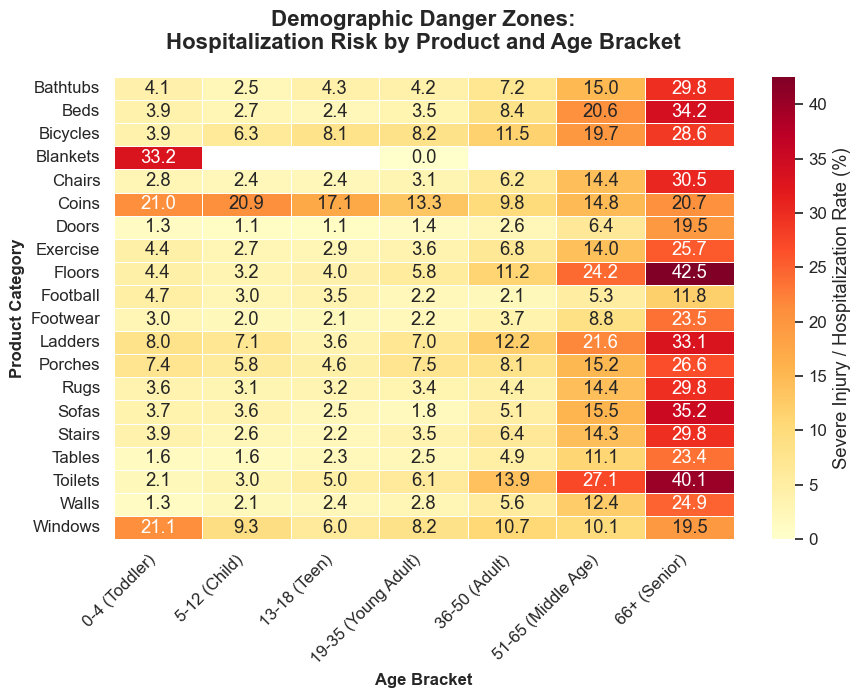

In [95]:
# 2. Set up the plotting canvas
plt.figure(figsize=(10, 6))

# 3. Generate the heatmap using Seaborn
# 'cmap="YlOrRd"' creates the Yellow-Orange-Red danger gradient.
# 'annot=True' ensures the actual percentage numbers are written inside the boxes.
ax = sns.heatmap(
    df_pivot, 
    annot=True, 
    fmt=".1f", 
    cmap="YlOrRd", 
    linewidths=.5, 
    cbar_kws={'label': 'Severe Injury / Hospitalization Rate (%)'}
)

# 4. Format the chart for the CSRI Publication
plt.title('Demographic Danger Zones:\nHospitalization Risk by Product and Age Bracket', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Age Bracket', fontsize=12, fontweight='bold')
plt.ylabel('Product Category', fontsize=12, fontweight='bold')

# Rotate x-axis labels slightly for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Tight layout ensures no labels get chopped off when saving
#plt.tight_layout()

# 5. Save the high-resolution image for your report
plt.savefig('demographic_danger_zone.png', dpi=300, bbox_inches='tight')
plt.show()

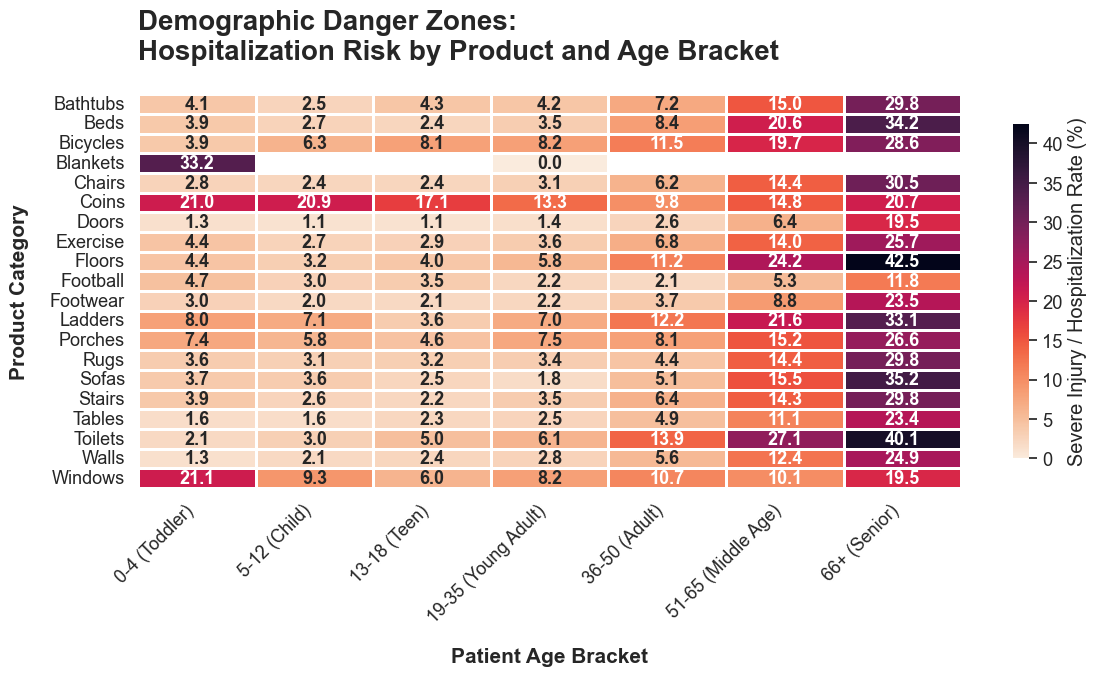

In [ ]:
# 1. Set a clean, high-contrast theme optimized for slides
# 'font_scale=1.2' globally increases text size so the back of the room can read it
sns.set_theme(style="white", font_scale=1.2)

# 2. Use the Object-Oriented setup for precise visual control
fig, ax = plt.subplots(figsize=(12, 7))

# 3. Generate the polished heatmap
# 'rocket_r' (reversed rocket) is a stunning, modern, presentation-grade palette
sns.heatmap(
    df_pivot, 
    annot=True, 
    fmt=".1f", 
    cmap="rocket_r",           # Sleek dark-purple to bright-orange/white gradient
    linewidths=2,              # Thicker 'trim' creates a beautiful grid effect
    linecolor='white',         # White trim completely modernizes the look
    annot_kws={"size": 13, "weight": "bold"}, # Ensures the numbers pop on the screen
    cbar_kws={
        'label': 'Severe Injury / Hospitalization Rate (%)',
        'shrink': 0.85,        # Elegantly shrinks the colorbar so it isn't clunky
        'aspect': 20,          # Makes the colorbar slightly thinner
        'pad': 0.05            # Adds a little breathing room between chart and colorbar
    },
    ax=ax
)

# 4. Editorial-style Presentation Formatting
# Left-aligned titles with heavy font weights look highly professional on slides
ax.set_title('Demographic Danger Zones:\nHospitalization Risk by Product and Age Bracket', 
             fontsize=20, pad=25, loc='left')

ax.set_xlabel('Patient Age Bracket', fontsize=15, fontweight='bold', labelpad=15)
ax.set_ylabel('Product Category', fontsize=15, fontweight='bold', labelpad=15)

# Clean up axes: rotate X, keep Y flat, and remove the tiny edge tick marks
plt.xticks(rotation=45, ha='right', fontsize=13)
plt.yticks(rotation=0, fontsize=13)
ax.tick_params(left=False, bottom=False) 

# Ensure no labels get chopped off
fig.tight_layout()

# 5. Save with a transparent background!
# transparent=True allows you to drop this directly onto a colored slide background seamlessly
plt.savefig('presentation_danger_zone.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

### 3. Risk Quadrant Plot

In [106]:
### Find the total injury for each procut group
product_injury_counts = train_data['product_category'].value_counts().reset_index()
product_injury_counts.columns = ['Product Category', 'Total_Injury_Volume']
product_injury_counts.head(10)

# Add the percentage of hospitalizations for each product category
hospitalization_counts = train_data.groupby('product_category')['Hospitalized'].sum().reset_index()
hospitalization_counts.columns = ['Product Category', 'Total Hospitalizations'] 

#compnine the two dataframes
product_injury_counts = product_injury_counts.merge(hospitalization_counts, on='Product Category')
product_injury_counts['Hospitalization_Rate_Pct'] = (product_injury_counts['Total Hospitalizations'] / product_injury_counts['Total_Injury_Volume']) * 100
product_injury_counts   

,Product Category,Total_Injury_Volume,Total Hospitalizations,Hospitalization_Rate_Pct
0,Stairs,415681,42248,10.16
1,Floors,375498,90820,24.19
2,Beds,248723,37731,15.17
3,Bicycles,181764,18165,9.99
4,Football,160019,5098,3.19
5,Chairs,119638,15470,12.93
6,Doors,110051,4175,3.79
7,Walls,109122,6482,5.94
8,Tables,105511,6039,5.72
9,Bathtubs,100085,12431,12.42


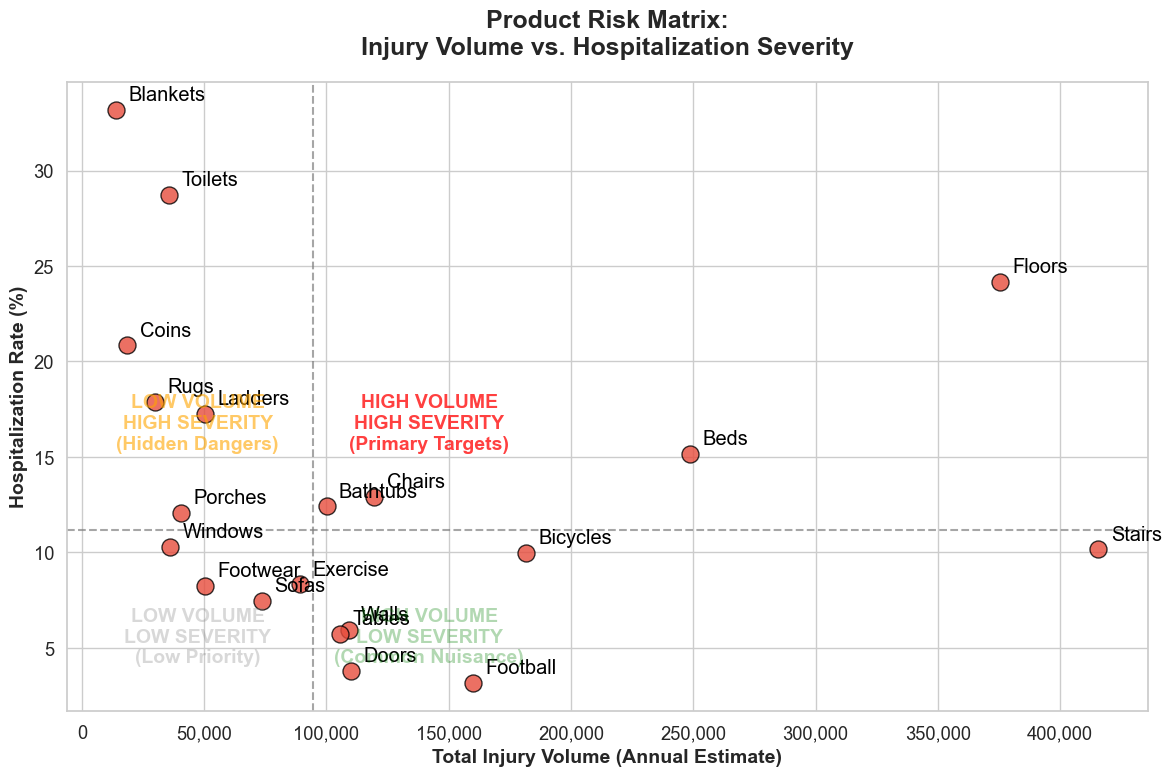

In [116]:

# 2. Calculate the medians to draw the quadrant dividing lines
median_volume = product_injury_counts['Total_Injury_Volume'].median()
median_severity = product_injury_counts['Hospitalization_Rate_Pct'].median()

# 3. Set up the plot canvas
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# 4. Create the scatter plot
ax = sns.scatterplot(
    data=product_injury_counts, 
    x='Total_Injury_Volume', 
    y='Hospitalization_Rate_Pct', 
    s=150,          # Size of the dots
    color='#e74c3c', # A professional alert red color
    edgecolor='black',
    alpha=0.8
)

# 5. Draw the Quadrant Lines (The crosshairs)
plt.axvline(median_volume, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axhline(median_severity, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

# 6. Annotate the points with the actual product names
for i in range(product_injury_counts.shape[0]):
    plt.text(
        product_injury_counts['Total_Injury_Volume'][i] + 5000,     # Offset text slightly to the right of the dot
        product_injury_counts['Hospitalization_Rate_Pct'][i] + 0.5, # Offset text slightly above the dot
        product_injury_counts['Product Category'][i],
        horizontalalignment='left',
        size='medium',
        color='black',
        #weight='semibold'
    )

# 7. Add bold background labels to identify the Quadrants for the audience
plt.text(median_volume * 1.5, median_severity * 1.5, 'HIGH VOLUME\nHIGH SEVERITY\n(Primary Targets)', 
         color='red', alpha=0.75, fontsize=14, fontweight='bold', ha='center', va='center')
plt.text(median_volume * 0.5, median_severity * 1.5, 'LOW VOLUME\nHIGH SEVERITY\n(Hidden Dangers)', 
         color='orange', alpha=0.60, fontsize=14, fontweight='bold', ha='center', va='center')
plt.text(median_volume * 1.5, median_severity * 0.5, 'HIGH VOLUME\nLOW SEVERITY\n(Common Nuisance)', 
         color='green', alpha=0.3, fontsize=14, fontweight='bold', ha='center', va='center')
plt.text(median_volume * 0.5, median_severity * 0.5, 'LOW VOLUME\nLOW SEVERITY\n(Low Priority)', 
         color='gray', alpha=0.3, fontsize=14, fontweight='bold', ha='center', va='center')

# 8. Format titles and labels for the CSRI report
plt.title('Product Risk Matrix:\nInjury Volume vs. Hospitalization Severity', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Total Injury Volume (Annual Estimate)', fontsize=14, fontweight='bold')
plt.ylabel('Hospitalization Rate (%)', fontsize=14, fontweight='bold')

# Format the X-axis numbers with commas (e.g., 400,000 instead of 400000)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()

# Save the high-resolution image
plt.savefig('risk_quadrant_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

### 4. Identify Relative Feature Importance

99 99
                  Feature  Importance Score
20      cat__Diagnosis_64              0.11
49      cat__Body_Part_85              0.07
13      cat__Diagnosis_57              0.06
15      cat__Diagnosis_59              0.05
9       cat__Diagnosis_53              0.05
30       cat__Body_Part_0              0.05
53      cat__Body_Part_92              0.04
18      cat__Diagnosis_62              0.04
98  remainder__Age_Scaled              0.03
45      cat__Body_Part_81              0.03


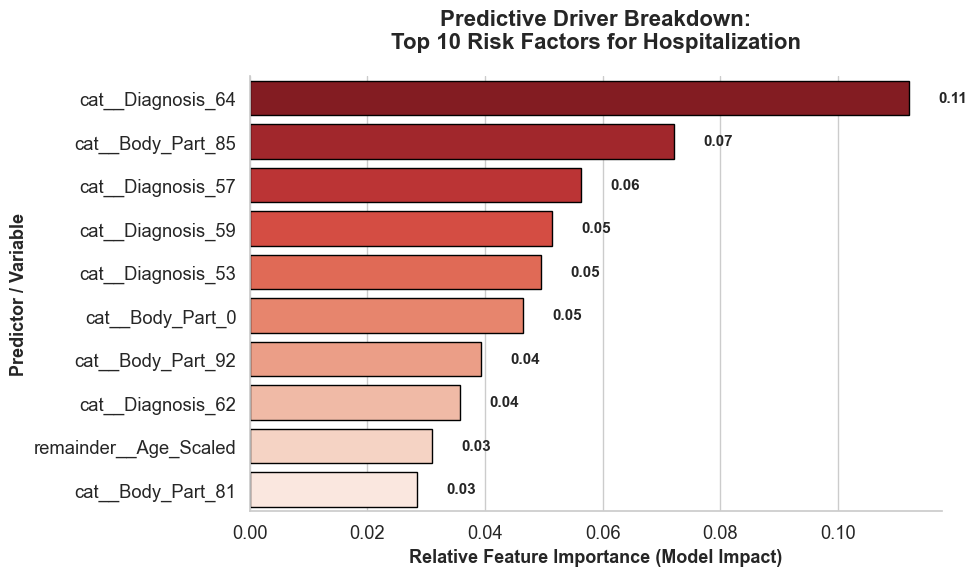

In [145]:
# Load the xbgoost joblib model file
model_filepath = '/Users/ananddivakaran/Documents/Anand/MDS/cpsa/models/neiss_XGboost.joblib'
xgb_model = joblib.load(model_filepath) 

# 1. Get the raw array of importance scores
scores = xgb_model.feature_importances_

# 2. Get the feature names from your training data (assuming X_train is a DataFrame)
features = encoded_train_data.columns[:-1]  # Exclude the target variable  

print(len(scores), len(features))

# 3. Combine them into a DataFrame
df_importance = pd.DataFrame({
    'Feature': features,
    'Importance Score': scores
})

# 4. Sort them
df_importance = df_importance.sort_values(by='Importance Score', ascending=False)

print(df_importance.head(10))

# 3. Set up the plotting canvas
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 4. Create the horizontal bar chart
# 'palette="Reds_r"' creates a gradient from dark red to light orange, emphasizing danger at the top
ax = sns.barplot(
    data=df_importance.head(10),
    x='Importance Score', 
    y='Feature',
    palette="Reds_r",
    #cmap = "YlGnBu",
    hue = 'Feature',  # Different color for each bar
    dodge=False,      # No separation between bars since hue is the same as y-axis
    edgecolor='black'
)

# 5. Add exact data labels to the end of each bar for clarity
for p in ax.patches:
    width = p.get_width()
    plt.text(
        width + 0.005,                   # X-coordinate offset slightly to the right of the bar
        p.get_y() + p.get_height() / 2,  # Y-coordinate centered on the bar
        f"{width:.2f}", 
        ha='left', 
        va='center', 
        fontsize=11,
        fontweight='bold'
    )

# 6. Format titles and labels for the CSRI report
plt.title('Predictive Driver Breakdown:\nTop 10 Risk Factors for Hospitalization', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Relative Feature Importance (Model Impact)', fontsize=13, fontweight='bold')
plt.ylabel('Predictor / Variable', fontsize=13, fontweight='bold')

# Remove the top and right borders for a cleaner, modern look
sns.despine()

plt.tight_layout()

# 7. Save the high-resolution image
plt.savefig('predictive_driver_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()